Threshold: 72


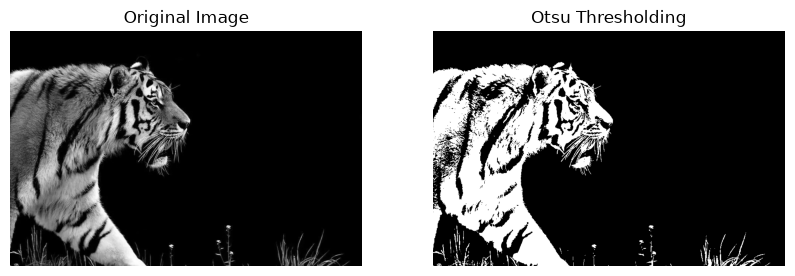

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
     

img = cv2.imread(r"D:\Sem-7\CV-LAB\image_exp5_tiger.png", cv2.IMREAD_GRAYSCALE)
     

hist = np.zeros(256)

for i in img.flatten():
    hist[i] += 1

total = img.size

max_variance = 0
threshold = 0
     

for t in range(256):
    w1 = np.sum(hist[:t+1])
    w2 = np.sum(hist[t+1:])
    if w1 == 0 or w2 == 0:
        continue
    mean1 = np.sum(np.arange(t+1) * hist[:t+1])/w1
    mean2 = np.sum(np.arange(t+1, 256) * hist[t+1:])/w2
    variance = w1 *w2*(mean1 - mean2) ** 2
    if variance > max_variance:
        max_variance = variance
        threshold = t
print("Threshold:", threshold)
     
Threshold: 152

result = np.zeros(img.shape, dtype=np.uint8)
result[img > threshold] = 255
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(result, cmap="gray")
plt.title("Otsu Thresholding")
plt.axis("off")
plt.show()